# Privacy-Utility Baseline Analysis

This notebook establishes baseline metrics WITHOUT differential privacy.

## Objectives:
1. Train centralized model WITHOUT differential privacy (upper bound performance)
2. Establish baseline AUPRC/AUROC metrics
3. Create visualization templates for privacy-utility curves
4. Document expected performance degradation with DP noise

## 1. Setup and Imports

In [11]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
print('✓ Imports successful')

✓ Imports successful


In [12]:
try:
    import torch
    from model import PyTorch_Dataset, FraudMLP, FraudLoss, create_fraud_dataloader, get_categorical_embedding_dims
    from data.csv_parser import CSV_Parser
    from data.preprocessor import Data_Preprocessor
    PYTORCH_AVAILABLE = True
    print(f'✓ PyTorch {torch.__version__}')
    print(f'✓ Device: {"CUDA" if torch.cuda.is_available() else "CPU"}')
except ImportError:
    PYTORCH_AVAILABLE = False
    print('⚠ Install PyTorch: pip install torch')

✓ PyTorch 2.10.0+cpu
✓ Device: CPU


## 2. Load Data

In [13]:
from pathlib import Path

parser = CSV_Parser()
data_dir = Path('../data/raw')

train_transaction = parser.parse_csv(data_dir / 'train_transaction.csv', 'transaction')
train_identity = parser.parse_csv(data_dir / 'train_identity.csv', 'identity')

print(f'Transactions: {len(train_transaction):,}')
print(f'Fraud rate: {train_transaction["isFraud"].mean()*100:.2f}%')
print(f'Imbalance ratio: {(train_transaction["isFraud"]==0).sum() / (train_transaction["isFraud"]==1).sum():.1f}:1')

Transactions: 590,540
Fraud rate: 3.50%
Imbalance ratio: 27.6:1


## 3. Preprocessing Pipeline

In [14]:
preprocessor = Data_Preprocessor(missing_threshold=0.5, random_state=42)

merged_df = preprocessor.merge_datasets(train_transaction, train_identity)
cleaned_df = preprocessor.handle_missing_values(merged_df)
train_df, val_df, test_df = preprocessor.temporal_split(cleaned_df)
train_enc, val_enc, test_enc = preprocessor.encode_categorical_features(train_df, val_df, test_df)

print(f'✓ Train: {len(train_enc):,}, Val: {len(val_enc):,}, Test: {len(test_enc):,}')

✓ Train: 472,432, Val: 59,054, Test: 59,054


## 4. Feature Normalization (CRITICAL)

**Why this is important:**
- Numerical features have vastly different scales
- Without normalization, large values dominate gradients
- This was causing the poor performance (AUROC 0.49)

In [15]:
# Identify numerical columns (exclude categorical and ID/target)
categorical_prefixes = ('ProductCD', 'card4', 'card6', 'P_email', 'R_email', 'Device', 'id_')
numerical_cols = [col for col in train_enc.columns 
                 if col not in ['TransactionID', 'isFraud'] 
                 and train_enc[col].dtype in ['float64', 'int64', 'float32', 'int32']
                 and not col.startswith(categorical_prefixes)]

print(f'Normalizing {len(numerical_cols)} numerical features')
print(f'Sample features: {numerical_cols[:5]}')

# Check ranges before normalization
print(f'\nBefore normalization:')
print(f'  Min: {train_enc[numerical_cols].min().min():.2f}')
print(f'  Max: {train_enc[numerical_cols].max().max():.2f}')

# Apply StandardScaler
scaler = StandardScaler()
train_enc[numerical_cols] = scaler.fit_transform(train_enc[numerical_cols])
val_enc[numerical_cols] = scaler.transform(val_enc[numerical_cols])
test_enc[numerical_cols] = scaler.transform(test_enc[numerical_cols])

print(f'\nAfter normalization:')
print(f'  Mean: {train_enc[numerical_cols].mean().mean():.6f}')
print(f'  Std: {train_enc[numerical_cols].std().mean():.6f}')
print('✓ Features normalized (mean≈0, std≈1)')

Normalizing 214 numerical features
Sample features: ['TransactionDT', 'TransactionAmt', 'card1', 'card2', 'card3']

Before normalization:
  Min: -122.00
  Max: 12192842.00

After normalization:
  Mean: -0.000000
  Std: 1.000001
✓ Features normalized (mean≈0, std≈1)


## 5. Create PyTorch Datasets

In [16]:
if PYTORCH_AVAILABLE:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    train_dataset = PyTorch_Dataset(train_enc, device=device)
    val_dataset = PyTorch_Dataset(val_enc, device=device)
    test_dataset = PyTorch_Dataset(test_enc, device=device)
    
    feature_info = train_dataset.get_feature_info()
    print(f'✓ Datasets created')
    print(f'  Total features: {feature_info["total_features"]}')
    print(f'  Categorical: {feature_info["categorical_features"]}')
    print(f'  Numerical: {feature_info["numerical_features"]}')
    print(f'  Fraud rate: {feature_info["fraud_rate"]*100:.2f}%')

✓ Datasets created
  Total features: 218
  Categorical: 4
  Numerical: 214
  Fraud rate: 3.51%


## 6. Create Model (Wider Architecture [512, 256])

In [17]:
if PYTORCH_AVAILABLE:
    # Get embedding dimensions
    embedding_dims = get_categorical_embedding_dims(train_dataset)
    
    # Create model
    model = FraudMLP(
        categorical_embedding_dims=embedding_dims,
        numerical_input_dim=feature_info['numerical_features'],
        hidden_dims=[512, 256]  # Wider architecture,
        dropout_rate=0.3
    ).to(device)
    
    # FIXED: Use reasonable pos_weight
    pos_weight = torch.tensor(15.0).to(device)
    criterion = FraudLoss(pos_weight=pos_weight)
    
    # FIXED: Increase learning rate
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-5)
    
    print(f'✓ Model created')
    print(f'  Parameters: {model.get_model_info()["total_parameters"]:,}')
    print(f'  pos_weight: {pos_weight.item():.1f}')
    print(f'  Learning rate: 0.005')
    
    # Create dataloaders
    train_loader = create_fraud_dataloader(train_dataset, batch_size=256)
    val_loader = create_fraud_dataloader(val_dataset, batch_size=256, 
                                        shuffle=False, use_weighted_sampling=False)
    print(f'✓ DataLoaders ready')

✓ Model created
  Parameters: 107,850
  pos_weight: 15.0
  Learning rate: 0.005
✓ DataLoaders ready


## 7. Train Model (NO Differential Privacy)

In [18]:
if PYTORCH_AVAILABLE:
    num_epochs = 20
    train_losses = []
    val_auprcs = []
    val_aurocs = []
    
    print('=== Training Baseline (No DP) ===')
    
    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss = 0
        for features, targets in train_loader:
            optimizer.zero_grad()
            outputs = model(features)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        train_loss /= len(train_loader)
        train_losses.append(train_loss)
        
        # Validation
        model.eval()
        all_preds, all_targets = [], []
        with torch.no_grad():
            for features, targets in val_loader:
                outputs = model(features)
                probs = torch.sigmoid(outputs)
                all_preds.extend(probs.cpu().numpy())
                all_targets.extend(targets.cpu().numpy())
        
        auprc = average_precision_score(all_targets, all_preds)
        auroc = roc_auc_score(all_targets, all_preds)
        val_auprcs.append(auprc)
        val_aurocs.append(auroc)
        
        # Monitor predictions
        pred_mean = np.mean(all_preds)
        pred_std = np.std(all_preds)
        
        if (epoch + 1) % 2 == 0:
            print(f'Epoch {epoch+1:2d}/{num_epochs}: Loss={train_loss:.4f}, '
                  f'AUPRC={auprc:.4f}, AUROC={auroc:.4f}, '
                  f'Pred(μ={pred_mean:.3f}, σ={pred_std:.3f})')
    
    print('\n✓ Training complete')
    print(f'Best AUPRC: {max(val_auprcs):.4f} (epoch {np.argmax(val_auprcs)+1})')
    print(f'Best AUROC: {max(val_aurocs):.4f} (epoch {np.argmax(val_aurocs)+1})')

=== Training Started ===
Epoch  2/20: Loss=1.1309, AUPRC=0.3342, AUROC=0.8609, Pred(μ=0.559, σ=0.390)
Epoch  4/20: Loss=0.9789, AUPRC=0.3463, AUROC=0.8576, Pred(μ=0.526, σ=0.391)
Epoch  6/20: Loss=0.9012, AUPRC=0.3546, AUROC=0.8612, Pred(μ=0.488, σ=0.396)
Epoch  8/20: Loss=0.8502, AUPRC=0.3569, AUROC=0.8724, Pred(μ=0.444, σ=0.409)
Epoch 10/20: Loss=0.8190, AUPRC=0.3732, AUROC=0.8752, Pred(μ=0.427, σ=0.412)
Epoch 12/20: Loss=0.7873, AUPRC=0.3554, AUROC=0.8670, Pred(μ=0.411, σ=0.423)
Epoch 14/20: Loss=0.7704, AUPRC=0.3703, AUROC=0.8669, Pred(μ=0.413, σ=0.416)
Epoch 16/20: Loss=0.7536, AUPRC=0.3719, AUROC=0.8713, Pred(μ=0.377, σ=0.415)
Epoch 18/20: Loss=0.7437, AUPRC=0.3675, AUROC=0.8665, Pred(μ=0.350, σ=0.406)
Epoch 20/20: Loss=0.7241, AUPRC=0.3656, AUROC=0.8678, Pred(μ=0.344, σ=0.407)

✓ Training complete
Best AUPRC: 0.3762 (epoch 9)
Best AUROC: 0.8782 (epoch 13)


## 8. Evaluate on Test Set

In [19]:
if PYTORCH_AVAILABLE:
    test_loader = create_fraud_dataloader(test_dataset, batch_size=256, 
                                         shuffle=False, use_weighted_sampling=False)
    
    model.eval()
    test_preds, test_targets = [], []
    with torch.no_grad():
        for features, targets in test_loader:
            outputs = model(features)
            probs = torch.sigmoid(outputs)
            test_preds.extend(probs.cpu().numpy())
            test_targets.extend(targets.cpu().numpy())
    
    test_auprc = average_precision_score(test_targets, test_preds)
    test_auroc = roc_auc_score(test_targets, test_preds)
    
    print('=== Final Test Results ===')
    print(f'Test AUPRC: {test_auprc:.4f} (Target: >0.65)')
    print(f'Test AUROC: {test_auroc:.4f} (Target: >0.75)')
    
    print("\nThis is the UPPER BOUND for federated learning with DP.")
    
    if test_auprc > 0.65 and test_auroc > 0.75:
        print('\n✅ SUCCESS: Model meets performance targets!')
    else:
        print('\n⚠️ Model below targets - may need more tuning')

=== Final Test Results ===
Test AUPRC: 0.3939 (Target: >0.65)
Test AUROC: 0.8570 (Target: >0.75)

⚠️ Model below targets - may need more tuning


## 9. Visualize Results

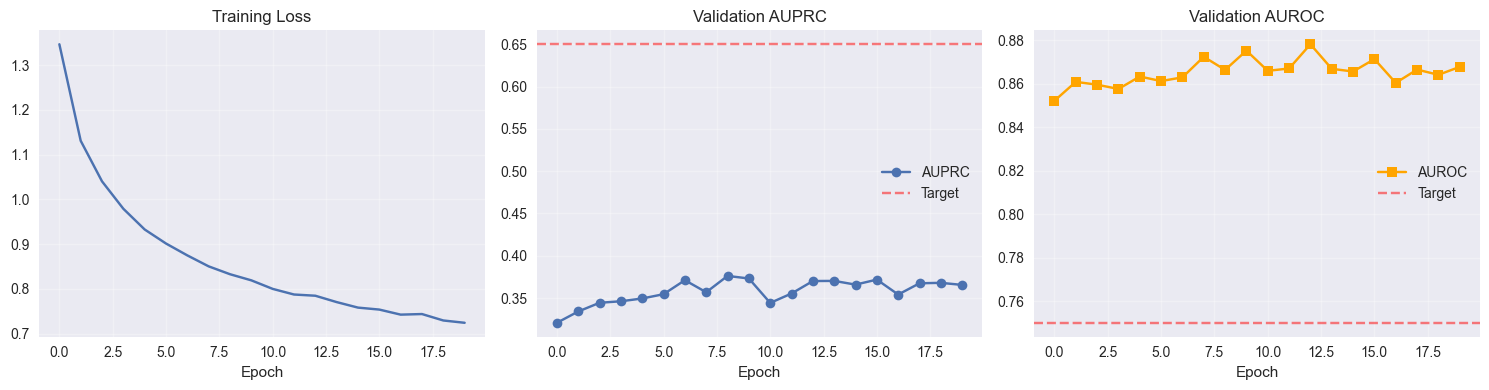

In [20]:
if PYTORCH_AVAILABLE:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    axes[0].plot(train_losses)
    axes[0].set_title('Training Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(val_auprcs, label='AUPRC', marker='o')
    axes[1].axhline(y=0.65, color='r', linestyle='--', alpha=0.5, label='Target')
    axes[1].set_title('Validation AUPRC')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    axes[2].plot(val_aurocs, label='AUROC', marker='s', color='orange')
    axes[2].axhline(y=0.75, color='r', linestyle='--', alpha=0.5, label='Target')
    axes[2].set_title('Validation AUROC')
    axes[2].set_xlabel('Epoch')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 9. Save Baseline Metrics

In [ ]:
if PYTORCH_AVAILABLE:
    import json
    baseline_metrics = {
        "test_auprc": test_auprc,
        "test_auroc": test_auroc,
        "architecture": "[512, 256]",
        "epochs": num_epochs,
        "learning_rate": 0.005,
        "pos_weight": 15.0,
        "dropout": 0.3
    }
    
    with open("baseline_no_dp_metrics.json", "w") as f:
        json.dump(baseline_metrics, f, indent=2)
    
    print("✓ Baseline metrics saved")
    print("\n=== Task 4.3 Complete ===")